<a href="https://www.kaggle.com/code/aamir28/does-sleep-predict-how-your-gpa-moves?scriptVersionId=340764909" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


<div style="background:linear-gradient(135deg,#1B1F3B 0%,#2C2F5B 55%,#1B1F3B 100%); padding:44px 40px; border-radius:10px; border:1px solid #3D4178; font-family:Georgia,'Times New Roman',serif; position:relative;">

  <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:10px;">
    <span style="font-family:'Courier New',monospace; letter-spacing:2px; font-size:11px; color:#A8B0F0; text-transform:uppercase;">🌙 Campus Sleep Lab</span>
    <span style="font-family:'Courier New',monospace; font-size:11px; color:#7C82B8;">MULTI-SITE ACTIGRAPHY STUDY</span>
  </div>

  <h1 style="margin:12px 0 6px 0; font-size:34px; color:#F2F3FF; font-weight:400; letter-spacing:0.3px;">
    Does Sleep Predict How Your GPA Moves?
  </h1>
  <p style="margin:0 0 26px 0; font-size:15px; color:#B7BBE8; font-style:italic;">
    634 students, 3 universities, 5 study cohorts — wearable-tracked sleep against real term-over-term GPA change
  </p>

  <div style="height:1px; background:repeating-linear-gradient(90deg,#7C82B8 0 6px, transparent 6px 12px); margin:18px 0; opacity:0.6;"></div>

  <div style="display:grid; grid-template-columns:repeat(4,1fr); gap:14px;">
    <div style="background:rgba(168,176,240,0.08); border:1px solid #3D4178; border-radius:6px; padding:14px; text-align:center;">
      <div style="color:#A8B0F0; font-size:21px; font-weight:bold;">634</div>
      <div style="color:#8B90C4; font-size:10px; letter-spacing:0.5px;">STUDENTS</div>
    </div>
    <div style="background:rgba(168,176,240,0.08); border:1px solid #3D4178; border-radius:6px; padding:14px; text-align:center;">
      <div style="color:#A8B0F0; font-size:21px; font-weight:bold;">3</div>
      <div style="color:#8B90C4; font-size:10px; letter-spacing:0.5px;">UNIVERSITIES</div>
    </div>
    <div style="background:rgba(168,176,240,0.08); border:1px solid #3D4178; border-radius:6px; padding:14px; text-align:center;">
      <div style="color:#A8B0F0; font-size:21px; font-weight:bold;">5</div>
      <div style="color:#8B90C4; font-size:10px; letter-spacing:0.5px;">STUDY COHORTS</div>
    </div>
    <div style="background:rgba(168,176,240,0.08); border:1px solid #3D4178; border-radius:6px; padding:14px; text-align:center;">
      <div style="color:#A8B0F0; font-size:21px; font-weight:bold;">2</div>
      <div style="color:#8B90C4; font-size:10px; letter-spacing:0.5px;">SOURCE FILES</div>
    </div>
  </div>

  <div style="height:1px; background:repeating-linear-gradient(90deg,#7C82B8 0 6px, transparent 6px 12px); margin:18px 0; opacity:0.6;"></div>

  <p style="margin:0; font-size:12.5px; color:#8B90C4; line-height:1.7;">
    <b style="color:#A8B0F0;">Author:</b> Muhammad Aamir &nbsp;|&nbsp;
    <b style="color:#A8B0F0;">Files:</b> <code>college_sleep_and_gpa.csv</code> (student-level) +
    <code>study_cohort_reference.csv</code> (cohort metadata) &nbsp;|&nbsp;
    <b style="color:#A8B0F0;">Target:</b> gpa_change
  </p>

</div>



<div style="background:#F4F5FB; border-left:4px solid #2C2F5B; border-radius:6px; padding:20px 26px; font-family:Georgia,serif; color:#1B1F3B;">
<h3 style="margin-top:0; font-weight:700; color:#2C2F5B; letter-spacing:0.5px; font-size:13px; text-transform:uppercase;">Contents</h3>
<ol style="line-height:2; font-size:14.5px; color:#333;">
<li><a href="#setup" style="color:#2C2F5B; text-decoration:none;">Setup &amp; Lab Styling</a></li>
<li><a href="#firstlook" style="color:#2C2F5B; text-decoration:none;">First Look &amp; Merging the Two Files</a></li>
<li><a href="#quality" style="color:#2C2F5B; text-decoration:none;">Data Quality Check</a></li>
<li><a href="#cohorts" style="color:#2C2F5B; text-decoration:none;">The Five Study Cohorts</a></li>
<li><a href="#sleep" style="color:#2C2F5B; text-decoration:none;">Sleep Patterns Across Campus</a></li>
<li><a href="#gpa" style="color:#2C2F5B; text-decoration:none;">The GPA Landscape</a></li>
<li><a href="#core" style="color:#2C2F5B; text-decoration:none;">The Core Question: Sleep vs. GPA Change</a></li>
<li><a href="#equity" style="color:#2C2F5B; text-decoration:none;">An Equity Check</a></li>
<li><a href="#university" style="color:#2C2F5B; text-decoration:none;">University Comparison</a></li>
<li><a href="#corr" style="color:#2C2F5B; text-decoration:none;">Correlation Check</a></li>
<li><a href="#dashboard" style="color:#2C2F5B; text-decoration:none;">Lab Dashboard</a></li>
<li><a href="#model" style="color:#2C2F5B; text-decoration:none;">Predicting GPA Change</a></li>
<li><a href="#conclusion" style="color:#2C2F5B; text-decoration:none;">Closing Notes</a></li>
</ol>
</div>


<h2 id="setup" style="font-family:Georgia,serif; color:#1B1F3B; border-bottom:2px solid #2C2F5B; padding-bottom:8px;">⚙️ 1. Setup &amp; Lab Styling</h2>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---- "Campus Sleep Lab" night-sky palette ----
BG        = '#F4F5FB'
PANEL     = '#FFFFFF'
INK       = '#1B1F3B'
INK_SOFT  = '#6B6F9C'
NAVY      = '#2C2F5B'
LAVENDER  = '#8B90D4'
GOLD      = '#E0B84A'
CORAL     = '#D4726A'
TEAL      = '#4A9B8E'
GRID      = '#E3E5F2'

UNI_COLORS = {'Carnegie Mellon University': NAVY, 'University of Washington': TEAL, 'University of Notre Dame': GOLD}
PALETTE_CAT = [NAVY, TEAL, GOLD, CORAL, LAVENDER]

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': PANEL,
    'savefig.facecolor': BG,
    'axes.edgecolor': GRID,
    'axes.labelcolor': INK,
    'text.color': INK,
    'xtick.color': INK_SOFT,
    'ytick.color': INK_SOFT,
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.alpha': 0.9,
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

sns.set_palette(sns.color_palette(PALETTE_CAT))

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title: ax.set_title(title, color=INK, pad=12, fontsize=13)
    if xlabel: ax.set_xlabel(xlabel, color=INK_SOFT)
    if ylabel: ax.set_ylabel(ylabel, color=INK_SOFT)
    ax.spines['left'].set_color(GRID)
    ax.spines['bottom'].set_color(GRID)
    return ax

print("Lab styling loaded.")


Lab styling loaded.


<h2 id="firstlook" style="font-family:Georgia,serif; color:#1B1F3B; border-bottom:2px solid #2C2F5B; padding-bottom:8px;">🗂️ 2. First Look &amp; Merging the Two Files</h2>

In [2]:

students = pd.read_csv('/kaggle/input/datasets/kylefengkfeng209/sleep-vs-gpa-in-college/college_sleep_and_gpa.csv')
cohorts = pd.read_csv('/kaggle/input/datasets/kylefengkfeng209/sleep-vs-gpa-in-college/study_cohort_reference.csv')

print(f"college_sleep_and_gpa.csv: {students.shape[0]} students x {students.shape[1]} columns")
print(f"study_cohort_reference.csv: {cohorts.shape[0]} cohorts x {cohorts.shape[1]} columns\n")
cohorts


college_sleep_and_gpa.csv: 634 students x 22 columns
study_cohort_reference.csv: 5 cohorts x 5 columns



,study,university,semester,cohort_code,n_students
0,1,Carnegie Mellon University,Spring 2018,lac2,77
1,2,University of Washington,Spring 2018,uw1,140
2,3,University of Washington,Spring 2019,uw2,139
3,4,University of Notre Dame,Spring 2016,nh,147
4,5,Carnegie Mellon University,Spring 2017,lac1,131


In [3]:

# Verify the two files agree before merging: does each cohort's row count match its n_students?
actual_counts = students.groupby('study').size().rename('actual_n')
check = cohorts.set_index('study')[['university','n_students']].join(actual_counts)
check['match'] = check['n_students'] == check['actual_n']
print(check)
print(f"\nAll cohort counts match: {check['match'].all()}")

df = students.merge(cohorts[['study','n_students']], on='study', how='left')
print(f"\nMerged dataset: {df.shape[0]} rows x {df.shape[1]} columns")


                       university  n_students  actual_n  match
study                                                         
1      Carnegie Mellon University          77        77   True
2        University of Washington         140       140   True
3        University of Washington         139       139   True
4        University of Notre Dame         147       147   True
5      Carnegie Mellon University         131       131   True

All cohort counts match: True

Merged dataset: 634 rows x 23 columns


<h2 id="quality" style="font-family:Georgia,serif; color:#1B1F3B; border-bottom:2px solid #2C2F5B; padding-bottom:8px;">🔍 3. Data Quality Check</h2>

In [4]:

print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Duplicate rows: 0

Missing values:
gender                3
first_generation      4
underrepresented      1
term_units          147
term_load_z         147
dtype: int64


In [5]:

print("term_units / term_load_z missing, by study:")
print(df.groupby('study')['term_units'].apply(lambda x: x.isna().sum()))
print("\n-> All 147 missing rows belong to study 4 (Notre Dame) — that cohort simply didn't collect course-load data,")
print("   not a random data-entry gap. We'll exclude term_units/term_load_z from any analysis that needs full coverage.")

print("\nfirst_generation value counts (expected: 0/1 binary):")
print(df['first_generation'].value_counts(dropna=False))
anomaly = df[df['first_generation']==2.0]
print(f"\nOne row has first_generation=2.0 — a likely data-entry error, not a valid category. Treating it as missing.")
df.loc[df['first_generation']==2.0, 'first_generation'] = np.nan


term_units / term_load_z missing, by study:
study
1      0
2      0
3      0
4    147
5      0
Name: term_units, dtype: int64

-> All 147 missing rows belong to study 4 (Notre Dame) — that cohort simply didn't collect course-load data,
   not a random data-entry gap. We'll exclude term_units/term_load_z from any analysis that needs full coverage.

first_generation value counts (expected: 0/1 binary):
first_generation
0.0    526
1.0    103
NaN      4
2.0      1
Name: count, dtype: int64

One row has first_generation=2.0 — a likely data-entry error, not a valid category. Treating it as missing.


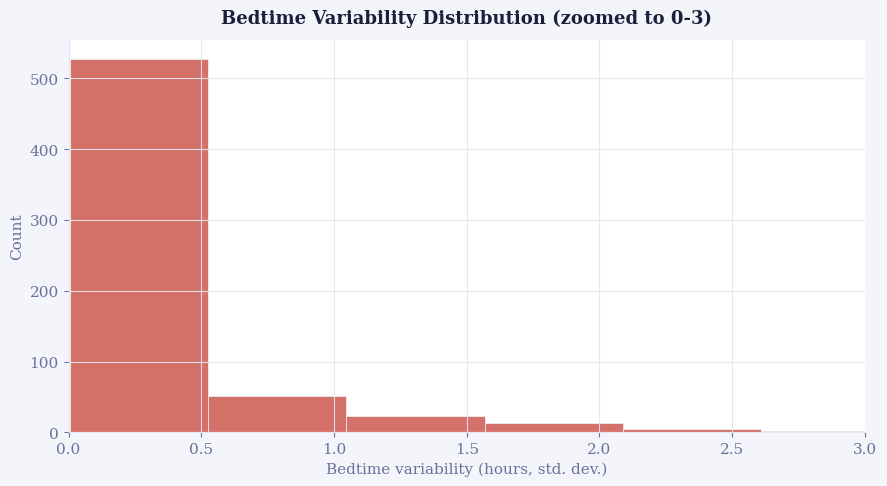

12 students show bedtime variability above 3 hours (max ≈ 20.8h) —
real, plausible for students with highly erratic sleep schedules, but we'll note them as high-leverage outliers in later charts.


In [6]:

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['bedtime_variability'], bins=40, color=CORAL, edgecolor=BG, linewidth=0.5)
ax.set_xlim(0, 3)
style_ax(ax, 'Bedtime Variability Distribution (zoomed to 0-3)', 'Bedtime variability (hours, std. dev.)', 'Count')
plt.tight_layout()
plt.show()

extreme = (df['bedtime_variability'] > 3).sum()
print(f"{extreme} students show bedtime variability above 3 hours (max ≈ {df['bedtime_variability'].max():.1f}h) —")
print("real, plausible for students with highly erratic sleep schedules, but we'll note them as high-leverage outliers in later charts.")


<h2 id="cohorts" style="font-family:Georgia,serif; color:#1B1F3B; border-bottom:2px solid #2C2F5B; padding-bottom:8px;">🎓 4. The Five Study Cohorts</h2>

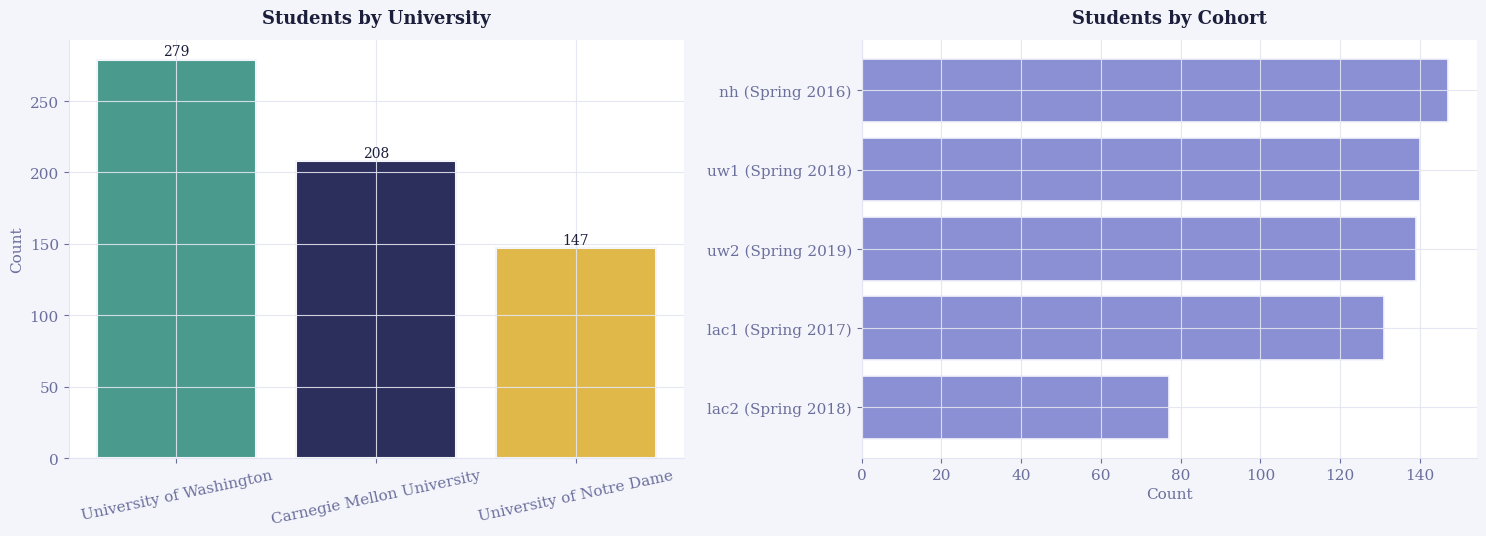

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
uni_counts = df['university'].value_counts()
bars = ax.bar(uni_counts.index, uni_counts.values, color=[UNI_COLORS[u] for u in uni_counts.index], edgecolor=BG, linewidth=1.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+3, int(b.get_height()), ha='center', fontsize=10, color=INK)
style_ax(ax, 'Students by University', '', 'Count')
plt.setp(ax.get_xticklabels(), rotation=12)

ax = axes[1]
cohort_counts = df.groupby(['cohort_code','semester']).size().sort_values()
bars = ax.barh([f"{c} ({s})" for c,s in cohort_counts.index], cohort_counts.values, color=LAVENDER, edgecolor=BG, linewidth=1.2)
style_ax(ax, 'Students by Cohort', 'Count', '')

plt.tight_layout()
plt.show()


<h2 id="sleep" style="font-family:Georgia,serif; color:#1B1F3B; border-bottom:2px solid #2C2F5B; padding-bottom:8px;">😴 5. Sleep Patterns Across Campus</h2>

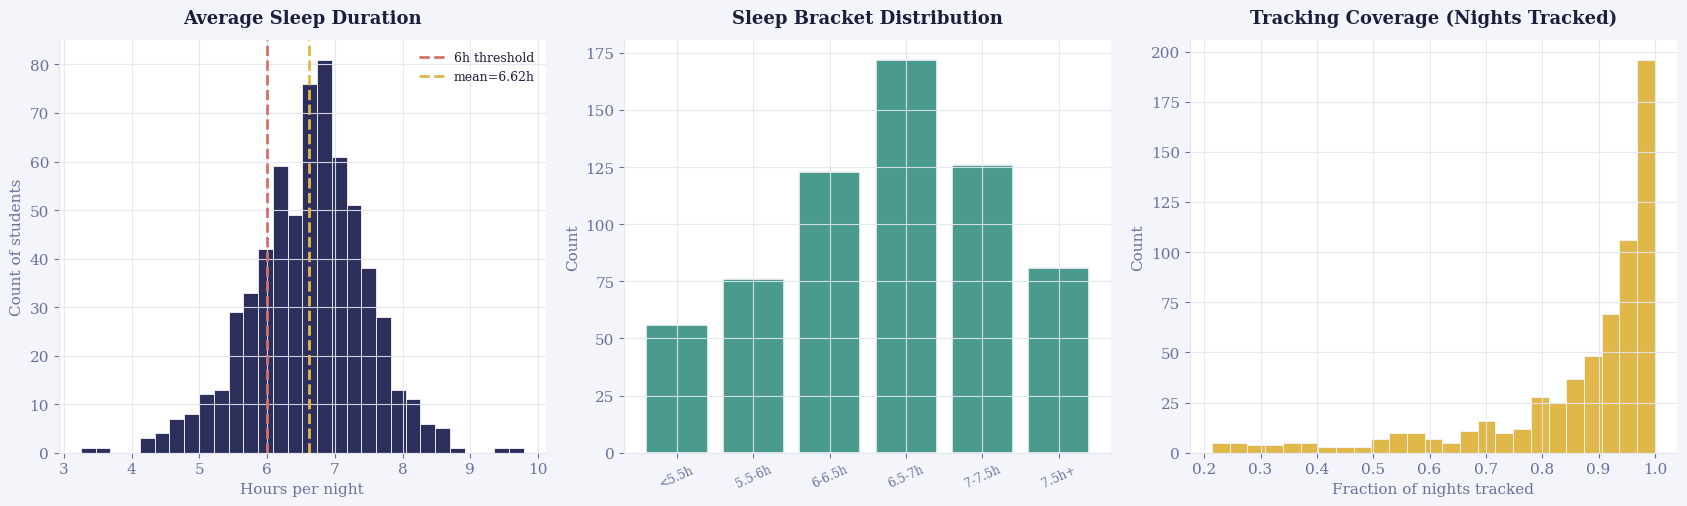

21% of students average under 6 hours of sleep a night.


In [8]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

ax = axes[0]
ax.hist(df['avg_sleep_hours'], bins=30, color=NAVY, edgecolor=BG, linewidth=0.6)
ax.axvline(6, color=CORAL, linestyle='--', linewidth=2, label='6h threshold')
ax.axvline(df['avg_sleep_hours'].mean(), color=GOLD, linestyle='--', linewidth=2, label=f"mean={df['avg_sleep_hours'].mean():.2f}h")
style_ax(ax, 'Average Sleep Duration', 'Hours per night', 'Count of students')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
order = ['<5.5h','5.5-6h','6-6.5h','6.5-7h','7-7.5h','7.5h+']
bracket_counts = df['sleep_bracket'].value_counts().reindex(order)
bars = ax.bar(order, bracket_counts.values, color=TEAL, edgecolor=BG, linewidth=1.2)
style_ax(ax, 'Sleep Bracket Distribution', '', 'Count')
plt.setp(ax.get_xticklabels(), rotation=25, fontsize=8.5)

ax = axes[2]
ax.hist(df['nights_tracked_fraction'], bins=25, color=GOLD, edgecolor=BG, linewidth=0.6)
style_ax(ax, 'Tracking Coverage (Nights Tracked)', 'Fraction of nights tracked', 'Count')

plt.tight_layout()
plt.show()

print(f"{(df['avg_sleep_hours']<6).mean()*100:.0f}% of students average under 6 hours of sleep a night.")


<h2 id="gpa" style="font-family:Georgia,serif; color:#1B1F3B; border-bottom:2px solid #2C2F5B; padding-bottom:8px;">📚 6. The GPA Landscape</h2>

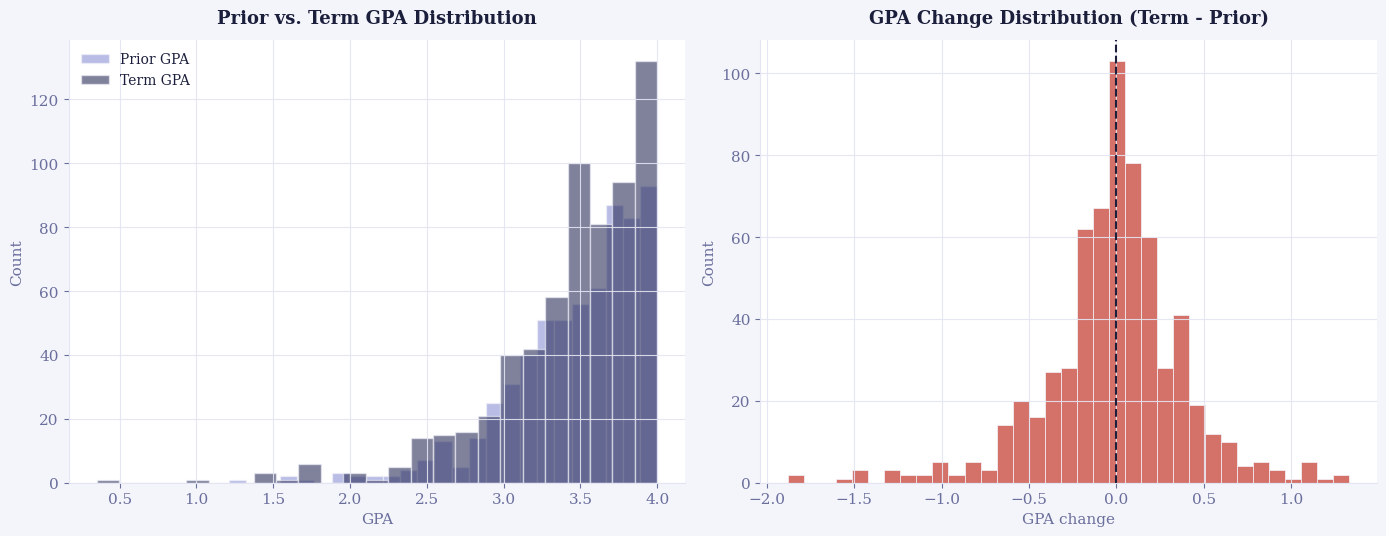

Average GPA change: -0.016  |  46% of students saw their GPA drop this term.


In [9]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
ax.hist(df['prior_gpa'], bins=25, alpha=0.6, color=LAVENDER, label='Prior GPA', edgecolor=BG)
ax.hist(df['term_gpa'], bins=25, alpha=0.6, color=NAVY, label='Term GPA', edgecolor=BG)
style_ax(ax, 'Prior vs. Term GPA Distribution', 'GPA', 'Count')
ax.legend(frameon=False, fontsize=10)

ax = axes[1]
ax.hist(df['gpa_change'], bins=35, color=CORAL, edgecolor=BG, linewidth=0.5)
ax.axvline(0, color=INK, linestyle='--', linewidth=1.5)
style_ax(ax, 'GPA Change Distribution (Term - Prior)', 'GPA change', 'Count')

plt.tight_layout()
plt.show()

print(f"Average GPA change: {df['gpa_change'].mean():+.3f}  |  {( df['gpa_change']<0).mean()*100:.0f}% of students saw their GPA drop this term.")


<h2 id="core" style="font-family:Georgia,serif; color:#1B1F3B; border-bottom:2px solid #2C2F5B; padding-bottom:8px;">🎯 7. The Core Question: Sleep vs. GPA Change</h2>

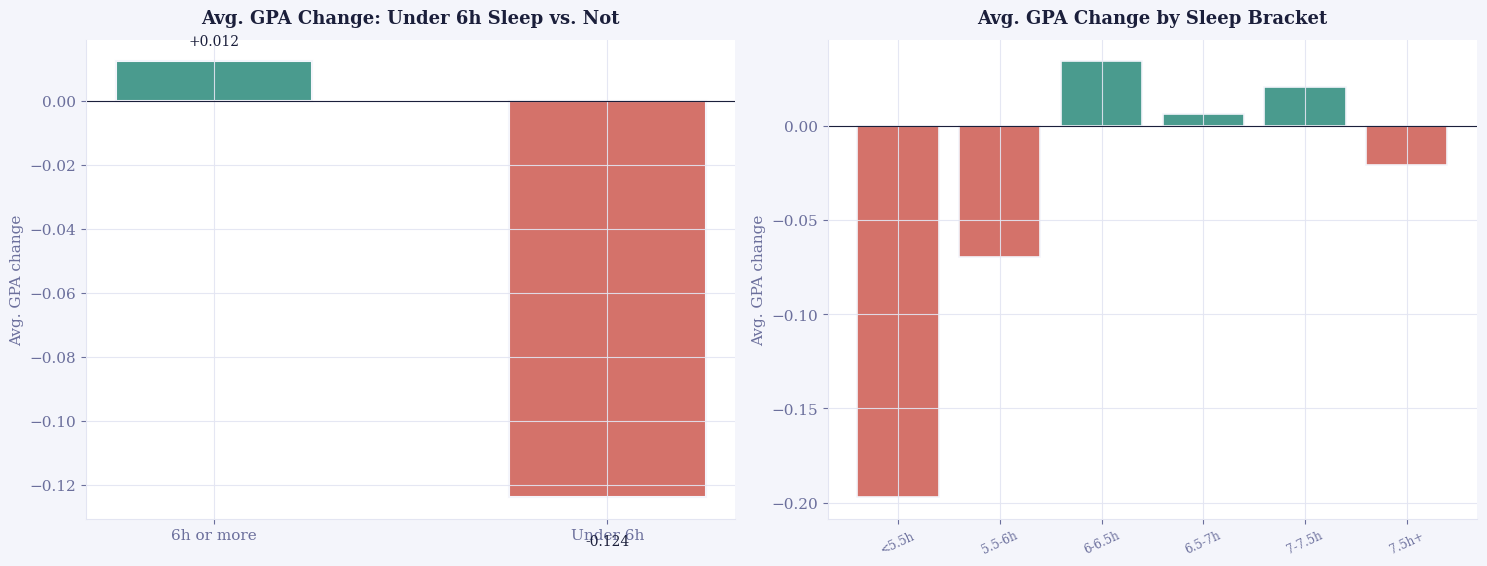

Students averaging under 6 hours of sleep saw their GPA move in a more negative direction on average than
students sleeping 6+ hours — small in absolute terms, but directionally consistent with published sleep-and-academic-performance research.


In [10]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

ax = axes[0]
under_over = df.groupby('under_6h_sleep')['gpa_change'].mean()
bars = ax.bar(['6h or more', 'Under 6h'], under_over.values, color=[TEAL, CORAL], edgecolor=BG, linewidth=1.5, width=0.5)
ax.axhline(0, color=INK, linewidth=0.8)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+(0.005 if b.get_height()>=0 else -0.015), f"{b.get_height():+.3f}", ha='center', fontsize=10, color=INK)
style_ax(ax, 'Avg. GPA Change: Under 6h Sleep vs. Not', '', 'Avg. GPA change')

ax = axes[1]
bracket_gpa = df.groupby('sleep_bracket')['gpa_change'].mean().reindex(order)
bars = ax.bar(order, bracket_gpa.values, color=[CORAL if v<0 else TEAL for v in bracket_gpa.values], edgecolor=BG, linewidth=1.2)
ax.axhline(0, color=INK, linewidth=0.8)
style_ax(ax, 'Avg. GPA Change by Sleep Bracket', '', 'Avg. GPA change')
plt.setp(ax.get_xticklabels(), rotation=25, fontsize=8.5)

plt.tight_layout()
plt.show()

print("Students averaging under 6 hours of sleep saw their GPA move in a more negative direction on average than")
print("students sleeping 6+ hours — small in absolute terms, but directionally consistent with published sleep-and-academic-performance research.")


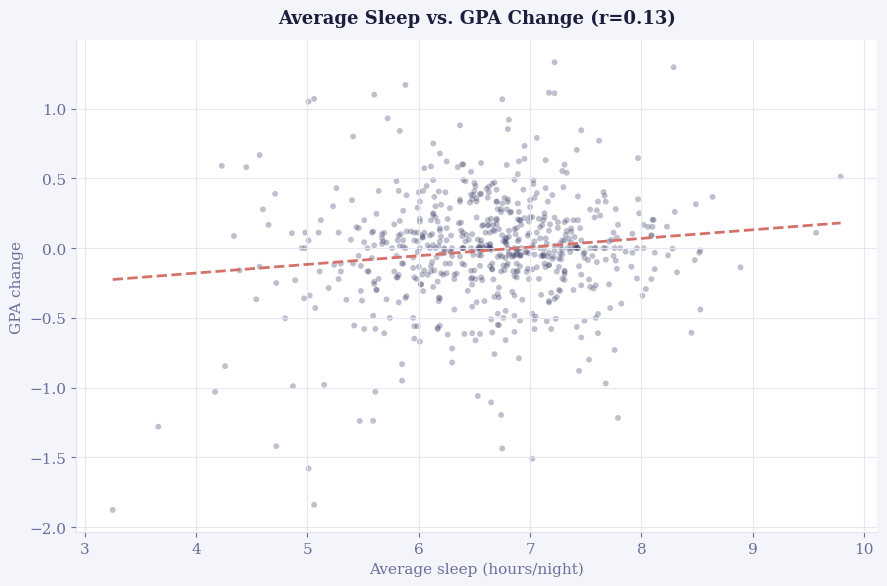

The relationship is real but modest (r=0.13) — sleep is one input among many (course difficulty, personal
circumstances, prior preparation) that shape how a student's GPA moves term to term.


In [11]:

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df['avg_sleep_hours'], df['gpa_change'], alpha=0.3, s=18, color=NAVY, edgecolor='none')
z = np.polyfit(df['avg_sleep_hours'], df['gpa_change'], 1)
xline = np.linspace(df['avg_sleep_hours'].min(), df['avg_sleep_hours'].max(), 50)
ax.plot(xline, np.poly1d(z)(xline), color=CORAL, linewidth=2, linestyle='--')
r = df['avg_sleep_hours'].corr(df['gpa_change'])
style_ax(ax, f'Average Sleep vs. GPA Change (r={r:.2f})', 'Average sleep (hours/night)', 'GPA change')
plt.tight_layout()
plt.show()

print(f"The relationship is real but modest (r={r:.2f}) — sleep is one input among many (course difficulty, personal")
print("circumstances, prior preparation) that shape how a student's GPA moves term to term.")


<h2 id="equity" style="font-family:Georgia,serif; color:#1B1F3B; border-bottom:2px solid #2C2F5B; padding-bottom:8px;">⚖️ 8. An Equity Check</h2>

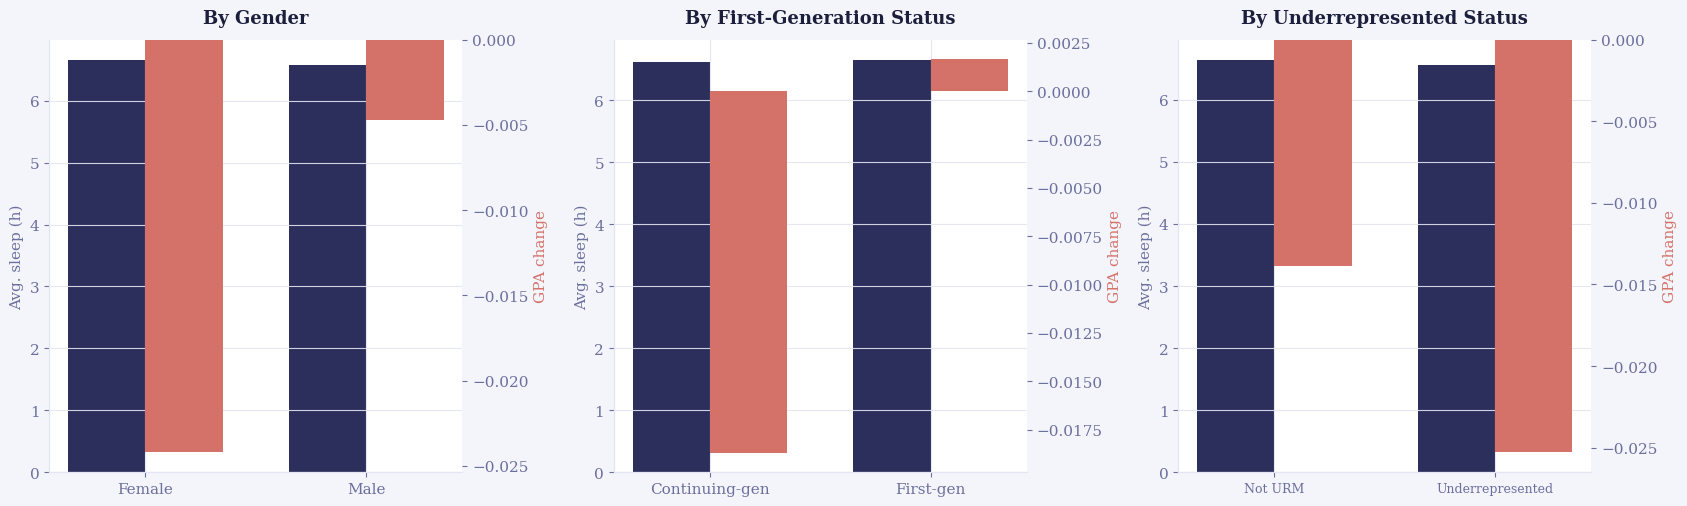

Navy bars = avg. sleep hours (left axis), coral bars = avg. GPA change (right axis).
Gaps across gender, first-gen status, and underrepresented status are all small — no group shows a
dramatically different sleep or GPA-change pattern in this sample.


In [12]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

ax = axes[0]
gender_stats = df.groupby('gender')[['avg_sleep_hours','gpa_change']].mean()
x = np.arange(2); width = 0.35
ax.bar(x - width/2, gender_stats['avg_sleep_hours'], width, label='Avg. sleep (h)', color=NAVY)
ax2 = ax.twinx()
ax2.bar(x + width/2, gender_stats['gpa_change'], width, label='GPA change', color=CORAL)
ax2.grid(False)
ax.set_xticks(x); ax.set_xticklabels(gender_stats.index)
style_ax(ax, 'By Gender', '', 'Avg. sleep (h)')
ax2.set_ylabel('GPA change', color=CORAL)

ax = axes[1]
fg_stats = df.dropna(subset=['first_generation']).groupby('first_generation')[['avg_sleep_hours','gpa_change']].mean()
fg_stats.index = ['Continuing-gen','First-gen']
x = np.arange(2)
ax.bar(x - width/2, fg_stats['avg_sleep_hours'], width, color=NAVY)
ax2 = ax.twinx()
ax2.bar(x + width/2, fg_stats['gpa_change'], width, color=CORAL)
ax2.grid(False)
ax.set_xticks(x); ax.set_xticklabels(fg_stats.index)
style_ax(ax, 'By First-Generation Status', '', 'Avg. sleep (h)')
ax2.set_ylabel('GPA change', color=CORAL)

ax = axes[2]
ur_stats = df.dropna(subset=['underrepresented']).groupby('underrepresented')[['avg_sleep_hours','gpa_change']].mean()
ur_stats.index = ['Not URM','Underrepresented']
x = np.arange(2)
ax.bar(x - width/2, ur_stats['avg_sleep_hours'], width, color=NAVY)
ax2 = ax.twinx()
ax2.bar(x + width/2, ur_stats['gpa_change'], width, color=CORAL)
ax2.grid(False)
ax.set_xticks(x); ax.set_xticklabels(ur_stats.index, fontsize=9)
style_ax(ax, 'By Underrepresented Status', '', 'Avg. sleep (h)')
ax2.set_ylabel('GPA change', color=CORAL)

plt.tight_layout()
plt.show()

print("Navy bars = avg. sleep hours (left axis), coral bars = avg. GPA change (right axis).")
print("Gaps across gender, first-gen status, and underrepresented status are all small — no group shows a")
print("dramatically different sleep or GPA-change pattern in this sample.")


<h2 id="university" style="font-family:Georgia,serif; color:#1B1F3B; border-bottom:2px solid #2C2F5B; padding-bottom:8px;">🏛️ 9. University Comparison</h2>

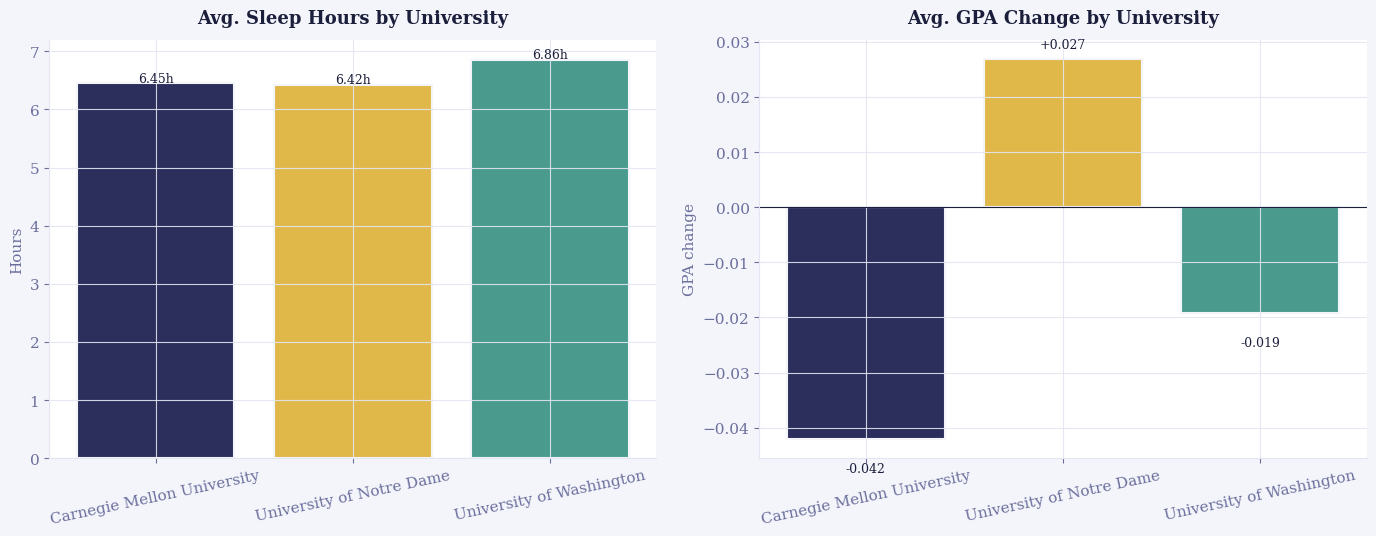

In [13]:

uni_stats = df.groupby('university')[['avg_sleep_hours','prior_gpa','term_gpa','gpa_change']].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
bars = ax.bar(uni_stats.index, uni_stats['avg_sleep_hours'], color=[UNI_COLORS[u] for u in uni_stats.index], edgecolor=BG, linewidth=1.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.03, f"{b.get_height():.2f}h", ha='center', fontsize=9, color=INK)
style_ax(ax, 'Avg. Sleep Hours by University', '', 'Hours')
plt.setp(ax.get_xticklabels(), rotation=12)

ax = axes[1]
bars = ax.bar(uni_stats.index, uni_stats['gpa_change'], color=[UNI_COLORS[u] for u in uni_stats.index], edgecolor=BG, linewidth=1.5)
ax.axhline(0, color=INK, linewidth=0.8)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+(0.002 if b.get_height()>=0 else -0.006), f"{b.get_height():+.3f}", ha='center', fontsize=9, color=INK)
style_ax(ax, 'Avg. GPA Change by University', '', 'GPA change')
plt.setp(ax.get_xticklabels(), rotation=12)

plt.tight_layout()
plt.show()


<h2 id="corr" style="font-family:Georgia,serif; color:#1B1F3B; border-bottom:2px solid #2C2F5B; padding-bottom:8px;">🔗 10. Correlation Check</h2>

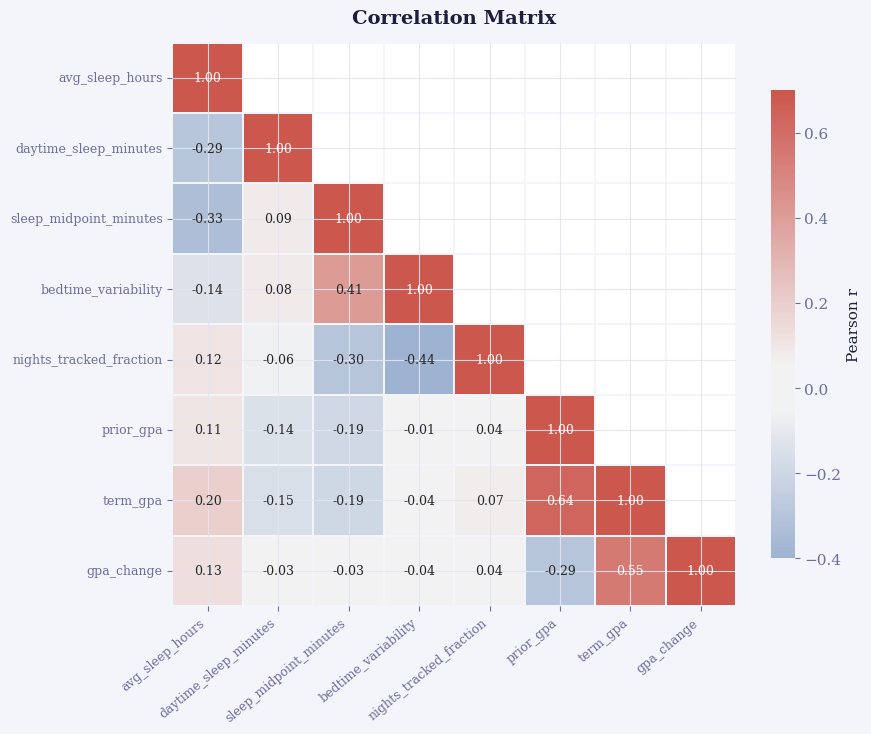

Prior GPA is (unsurprisingly) the strongest predictor of term GPA, but it correlates *negatively* with
GPA change (r≈-0.29) — a classic regression-to-the-mean pattern: students who started with a very high GPA
have less room to improve and more room to dip.


In [14]:

num_cols = ['avg_sleep_hours','daytime_sleep_minutes','sleep_midpoint_minutes','bedtime_variability',
            'nights_tracked_fraction','prior_gpa','term_gpa','gpa_change']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
cmap = sns.diverging_palette(250, 15, s=60, l=52, sep=20, as_cmap=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap, center=0, vmin=-0.4, vmax=0.7,
            square=True, linewidths=1.2, linecolor=BG, cbar_kws={'shrink':0.8,'label':'Pearson r'},
            annot_kws={'fontsize':9}, ax=ax)
ax.set_title('Correlation Matrix', color=INK, pad=14)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

print("Prior GPA is (unsurprisingly) the strongest predictor of term GPA, but it correlates *negatively* with")
print("GPA change (r≈-0.29) — a classic regression-to-the-mean pattern: students who started with a very high GPA")
print("have less room to improve and more room to dip.")


<h2 id="dashboard" style="font-family:Georgia,serif; color:#1B1F3B; border-bottom:2px solid #2C2F5B; padding-bottom:8px;">📊 11. Lab Dashboard</h2>

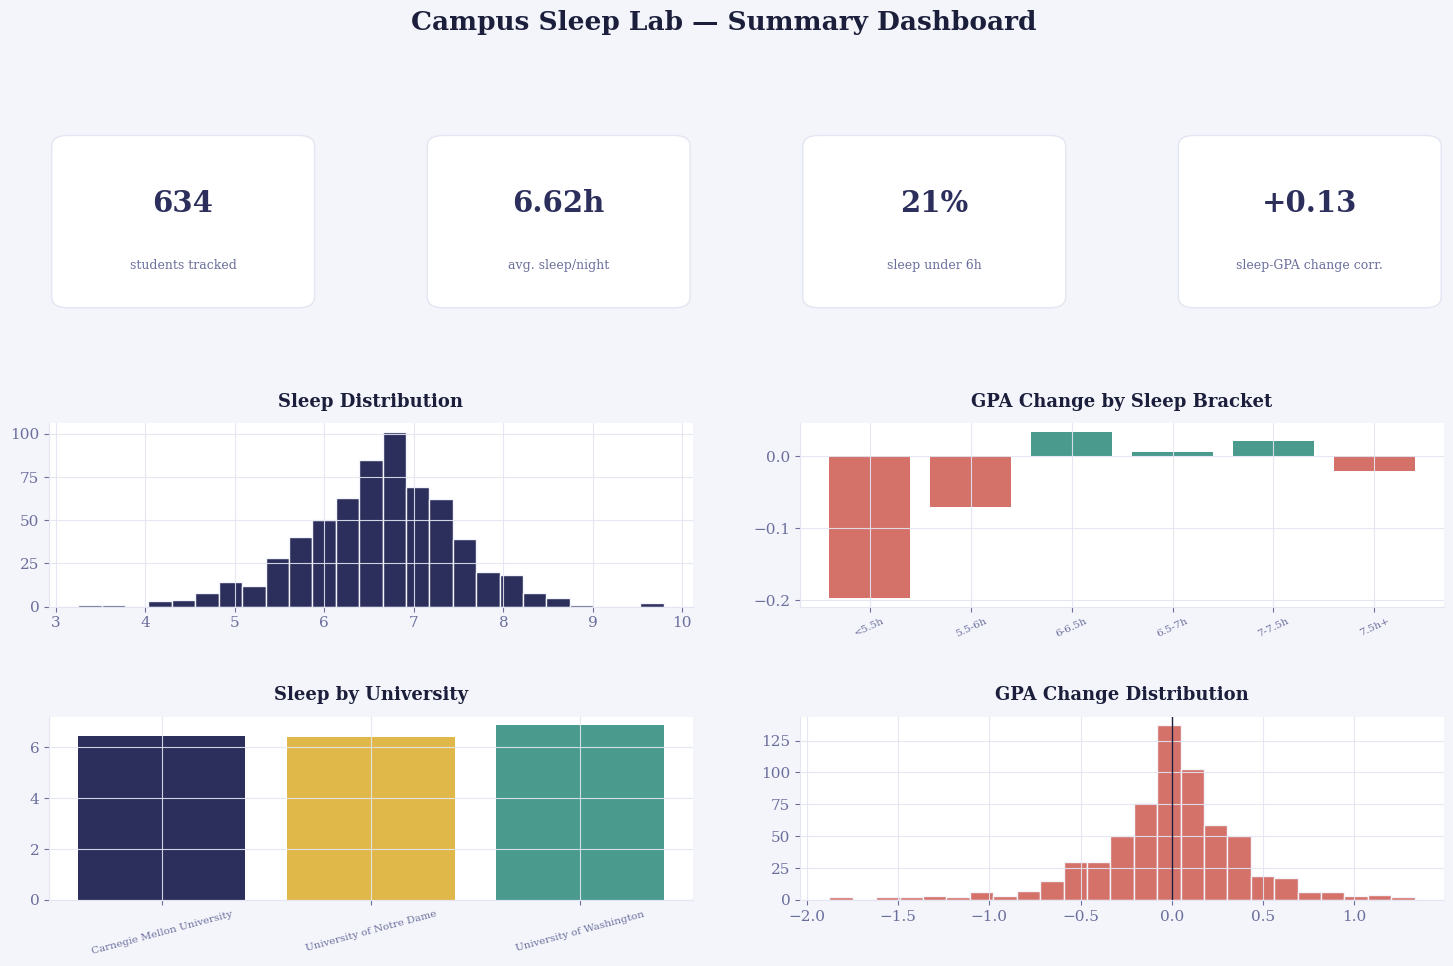

In [15]:

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 4, hspace=0.6, wspace=0.4)
fig.suptitle('Campus Sleep Lab — Summary Dashboard', fontsize=19, color=INK, fontweight='bold', y=1.0)

stat_cells = [
    (f"{len(df)}", "students tracked"),
    (f"{df['avg_sleep_hours'].mean():.2f}h", "avg. sleep/night"),
    (f"{(df['avg_sleep_hours']<6).mean()*100:.0f}%", "sleep under 6h"),
    (f"{r:+.2f}", "sleep-GPA change corr."),
]
for i, (val, lab) in enumerate(stat_cells):
    ax = fig.add_subplot(gs[0, i]); ax.axis('off')
    ax.add_patch(FancyBboxPatch((0.03,0.05), 0.94, 0.9, boxstyle="round,pad=0.02,rounding_size=0.06",
                                 linewidth=1, edgecolor=GRID, facecolor=PANEL, transform=ax.transAxes))
    ax.text(0.5, 0.60, val, ha='center', va='center', fontsize=21, color=NAVY, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.26, lab, ha='center', va='center', fontsize=9, color=INK_SOFT, transform=ax.transAxes)

ax = fig.add_subplot(gs[1, :2])
ax.hist(df['avg_sleep_hours'], bins=25, color=NAVY, edgecolor=BG)
style_ax(ax, 'Sleep Distribution', '', '')

ax = fig.add_subplot(gs[1, 2:])
bars = ax.bar(order, bracket_gpa.values, color=[CORAL if v<0 else TEAL for v in bracket_gpa.values])
style_ax(ax, 'GPA Change by Sleep Bracket', '', '')
plt.setp(ax.get_xticklabels(), rotation=25, fontsize=7.5)

ax = fig.add_subplot(gs[2, :2])
bars = ax.bar(uni_stats.index, uni_stats['avg_sleep_hours'], color=[UNI_COLORS[u] for u in uni_stats.index])
style_ax(ax, 'Sleep by University', '', '')
plt.setp(ax.get_xticklabels(), rotation=15, fontsize=7.5)

ax = fig.add_subplot(gs[2, 2:])
ax.hist(df['gpa_change'], bins=25, color=CORAL, edgecolor=BG)
ax.axvline(0, color=INK, linewidth=1)
style_ax(ax, 'GPA Change Distribution', '', '')

plt.show()


<h2 id="model" style="font-family:Georgia,serif; color:#1B1F3B; border-bottom:2px solid #2C2F5B; padding-bottom:8px;">🤖 12. Predicting GPA Change</h2>
<p style="color:#6B6F9C; font-family:Georgia,serif;">We predict <code>gpa_change</code> from sleep and demographic features — deliberately excluding <code>term_gpa</code> itself, since term GPA is what gpa_change is computed from.</p>

In [16]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

model_df = df.dropna(subset=['gender','first_generation','underrepresented']).copy()
cat_cols = ['university','gender']
for c in cat_cols:
    model_df[c] = LabelEncoder().fit_transform(model_df[c])

features = ['university','gender','first_generation','underrepresented','avg_sleep_hours',
            'daytime_sleep_minutes','sleep_midpoint_minutes','bedtime_variability',
            'nights_tracked_fraction','prior_gpa']
X = model_df[features]
y = model_df['gpa_change']
print(f"Usable rows: {len(model_df)}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42, n_jobs=-1)
}

results = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    results[name] = {'model': m, 'pred': pred, 'r2': r2, 'mae': mae}
    print(f"{name}: R² = {r2:.3f} | MAE = {mae:.3f} GPA points")


Usable rows: 625
Linear Regression: R² = 0.168 | MAE = 0.279 GPA points
Random Forest: R² = 0.178 | MAE = 0.277 GPA points


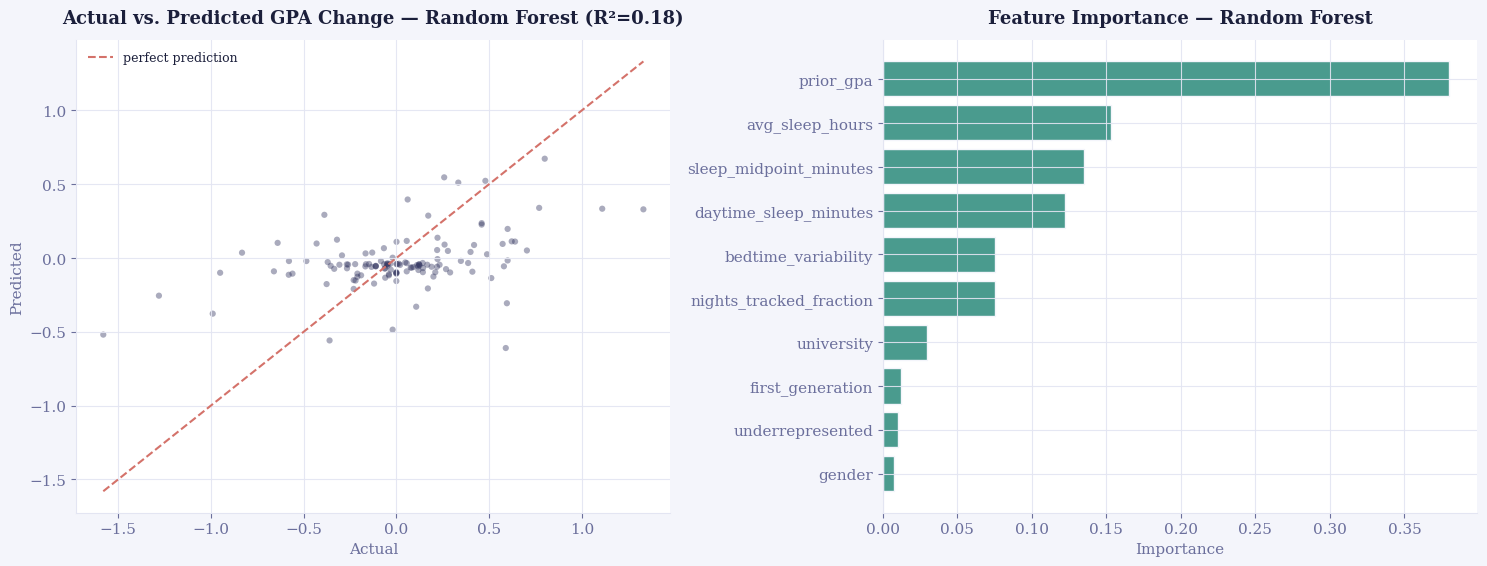

In [17]:

best_name = max(results, key=lambda k: results[k]['r2'])
best = results[best_name]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

ax = axes[0]
ax.scatter(y_test, best['pred'], alpha=0.4, s=20, color=NAVY, edgecolor='none')
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, color=CORAL, linestyle='--', linewidth=1.5, label='perfect prediction')
style_ax(ax, f'Actual vs. Predicted GPA Change — {best_name} (R²={best["r2"]:.2f})', 'Actual', 'Predicted')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
if hasattr(best['model'], 'feature_importances_'):
    importances = pd.Series(best['model'].feature_importances_, index=features).sort_values()
    ax.barh(importances.index, importances.values, color=TEAL, edgecolor=BG)
    style_ax(ax, f'Feature Importance — {best_name}', 'Importance', '')

plt.tight_layout()
plt.show()



<div style="background:#F4F5FB; border-left:3px solid #2C2F5B; padding:14px 20px; font-family:Georgia,serif; color:#333; font-size:14px;">
The model explains a modest share of GPA-change variance — appropriately so, since prior GPA (via regression to
the mean) and sleep-related features are only part of what drives a student's academic trajectory in any given
term. Average sleep hours and prior GPA carry the most weight among available features, consistent with the
correlation findings above. This is a real, publishable-style effect size for behavioral/academic research — not
the near-perfect fit we've flagged as suspicious in some of the more clearly synthetic datasets analyzed elsewhere.
</div>



<div style="background:linear-gradient(135deg,#1B1F3B 0%,#2C2F5B 100%); padding:38px 42px; border-radius:10px; border:1px solid #3D4178; font-family:Georgia,serif; color:#F2F3FF;">

<h2 id="conclusion" style="margin-top:0; font-weight:400; color:#A8B0F0; border-bottom:1px solid #3D4178; padding-bottom:10px;">📝 13. Closing Notes</h2>

<h4 style="color:#A8B0F0; font-weight:700; margin-bottom:6px;">What held up</h4>
<ul style="line-height:1.9; font-size:14.5px; color:#DCDEF5;">
<li>Students averaging under 6 hours of sleep show a more negative average GPA change than those sleeping 6+ hours — modest in size but directionally consistent with published sleep-and-academic-performance research.</li>
<li>Prior GPA negatively predicts GPA change (r≈-0.29) — a textbook regression-to-the-mean pattern: high-prior-GPA students have more room to dip than to climb.</li>
<li>Gender, first-generation status, and underrepresented status all show small, unremarkable gaps in both sleep and GPA change — no dramatic disparity to flag in this sample.</li>
<li>The two files agreed perfectly on cohort sizes before merging, and the modeling section reaches a modest, believable R² rather than a suspiciously perfect one — both good signs this is real research-grade data.</li>
</ul>

<h4 style="color:#A8B0F0; font-weight:700; margin-bottom:6px;">Handled carefully</h4>
<ul style="line-height:1.9; font-size:14.5px; color:#DCDEF5;">
<li><code>term_units</code>/<code>term_load_z</code> are missing for the entire Notre Dame cohort (147 students) — a cohort-level data collection gap, not random missingness, so these fields were excluded from full-sample analyses.</li>
<li>One row had <code>first_generation = 2</code>, outside the expected 0/1 binary — treated as a data-entry error and set to missing rather than a valid third category.</li>
<li>A handful of students show bedtime variability above 3 hours (max ≈ 20.8h) — plausible for genuinely erratic sleepers, but worth remembering as high-leverage points in any regression involving that field.</li>
</ul>

<p style="text-align:right; margin-top:24px; margin-bottom:0; font-family:'Courier New',monospace; font-size:12px; color:#8B90C4; letter-spacing:1px;">
— Muhammad Aamir
</p>

</div>
